### Prophet Forecasting Functions

To avoid repeating forecasting code multiple times, reusable Prophet functions are created for:
- preparing monthly time-series data,
- training Prophet models,
- generating future forecasts,
- and plotting predictions.

This improves code readability, modularity, and scalability across different fintech complaint categories.

#### Import libraries

In [1]:
import pandas as pd

from prophet import Prophet

import matplotlib.pyplot as plt

c:\Users\HP\anaconda3\envs\learn-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [9]:
cleaned_df = pd.read_csv('cleaned_data.csv', keep_default_na=False)
cleaned_df.head()

,reviewId,content,score,thumbsUpCount,at,appVersion,app_name,sentiment,with_emojis,cleaned_text,...,tokens_no_stopwords,meaningful_tokens,stemmed_tokens,lemmatized_tokens,processed_text,sentiment_label,complaint_label,fraud_indicator,review_length,word_count
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,"The app still has issues on OTP, because I hav...",1,0,2026-05-11 11:38:40,5.1.7,mpesa,negative,False,the app still has issues on otp because i have...,...,"['still', 'issues', 'otp', 'havent', 'received...","['still', 'issues', 'otp', 'havent', 'received...","['still', 'issu', 'otp', 'havent', 'receiv', '...","['still', 'issue', 'otp', 'havent', 'received'...",still issue otp havent received otp login trie...,negative,app_issue,0,173,26
1,acd5c061-de13-474b-8645-f628044f2a50,si everytime nitakuwa na bundles za ku check m...,2,0,2026-05-11 11:22:24,5.1.1,mpesa,negative,False,si everytime nitakuwa na bundles za ku check m...,...,"['si', 'everytime', 'nitakuwa', 'na', 'bundles...","['everytime', 'nitakuwa', 'bundles', 'check', ...","['everytim', 'nitakuwa', 'bundl', 'check', 'nu...","['everytime', 'nitakuwa', 'bundle', 'check', '...",everytime nitakuwa bundle check number try fix...,negative,general,0,95,16
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,this is the stupidest app ever from saf. the w...,1,0,2026-05-11 11:16:47,5.1.7,mpesa,negative,False,this is the stupidest app ever from saf the worst,...,"['stupidest', 'ever', 'saf', 'worst']","['stupidest', 'ever', 'saf', 'worst']","['stupidest', 'ever', 'saf', 'worst']","['stupidest', 'ever', 'saf', 'worst']",stupidest ever saf worst,negative,general,0,24,4
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,Life must go on without this useless app. It u...,1,0,2026-05-11 11:01:23,1.14.2,mpesa,negative,False,life must go on without this useless app it us...,...,"['life', 'must', 'go', 'without', 'useless', '...","['life', 'must', 'without', 'useless', 'used',...","['life', 'must', 'without', 'useless', 'use', ...","['life', 'must', 'without', 'useless', 'used',...",life must without useless used work well data ...,negative,general,0,64,12
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,the upgrade is terrible,1,0,2026-05-11 10:45:52,Unknown,mpesa,negative,False,the upgrade is terrible,...,"['upgrade', 'terrible']","['upgrade', 'terrible']","['upgrad', 'terribl']","['upgrade', 'terrible']",upgrade terrible,negative,general,0,16,2


### Forecasting Negative Complaint Volume

This forecasting model predicts future negative fintech complaint trends using Facebook Prophet.

The goal is to identify future spikes in customer dissatisfaction and financial distress.

In [14]:
# Convert the 'at' column to datetime format
cleaned_df['at'] = pd.to_datetime(cleaned_df['at'])

In [28]:
def prophet_forecast(
    data,
    date_col,
    title,
    periods=6
):

    # Monthly aggregation
    ts = (
        data
        .groupby(
            pd.Grouper(
                key=date_col,
                freq='ME'
            )
        )
        .size()
        .reset_index(name='y')
        .rename(columns={date_col: 'ds'})
    )

    # Train model
    model = Prophet()

    model.fit(ts)

    # Future prediction
    future = model.make_future_dataframe(
        periods=periods,
        freq='ME'
    )

    forecast = model.predict(future)

    # Plot
    model.plot(forecast)

    plt.title(title)

    plt.show()

    return forecast

def prophet_forecast(
    data,
    date_col,
    title,
    periods=6
):

    # Monthly aggregation
    ts = (
        data
        .groupby(
            pd.Grouper(
                key=date_col,
                freq='ME'
            )
        )
        .size()
        .reset_index(name='y')
        .rename(columns={date_col: 'ds'})
    )

    # Train model
    model = Prophet()

    model.fit(ts)

    # Future prediction
    future = model.make_future_dataframe(
        periods=periods,
        freq='ME'
    )

    forecast = model.predict(future)

    # Plot
    model.plot(forecast)

    plt.title(title)

    plt.show()

    return forecast

Forecast Negative Complaints

16:24:10 - cmdstanpy - INFO - Chain [1] start processing
16:24:11 - cmdstanpy - INFO - Chain [1] done processing


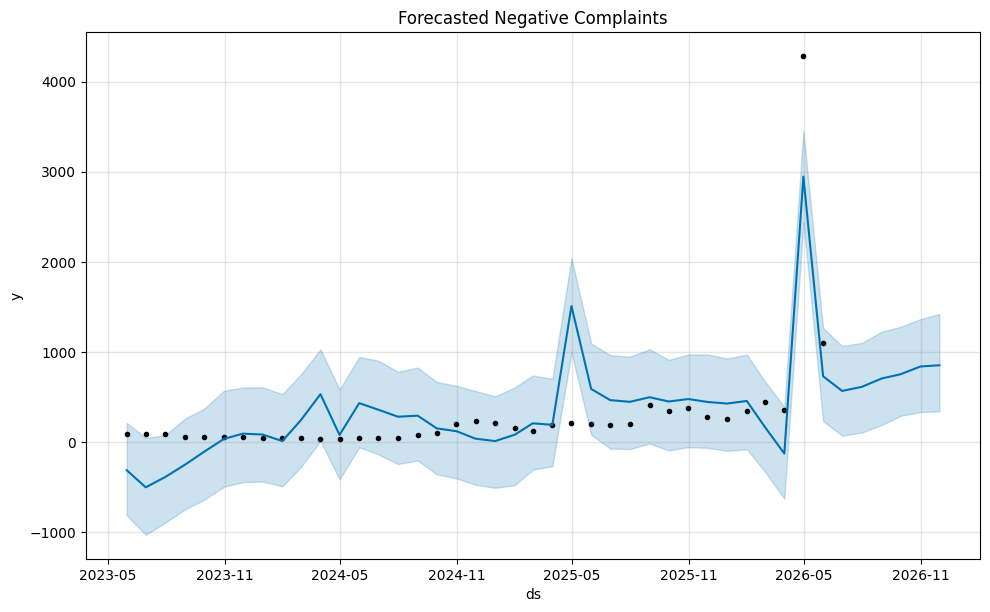

In [29]:
negative_forecast = prophet_forecast(
    data=cleaned_df[cleaned_df['sentiment_label'] == 'negative'],
    date_col='at',
    title='Forecasted Negative Complaints'
)

The forecast shows an upward trend in complaint volume over time, suggesting that user dissatisfaction and financial distress may continue increasing if service issues are not addressed.

Forecast Fraud Complaints

16:25:31 - cmdstanpy - INFO - Chain [1] start processing
16:25:32 - cmdstanpy - INFO - Chain [1] done processing


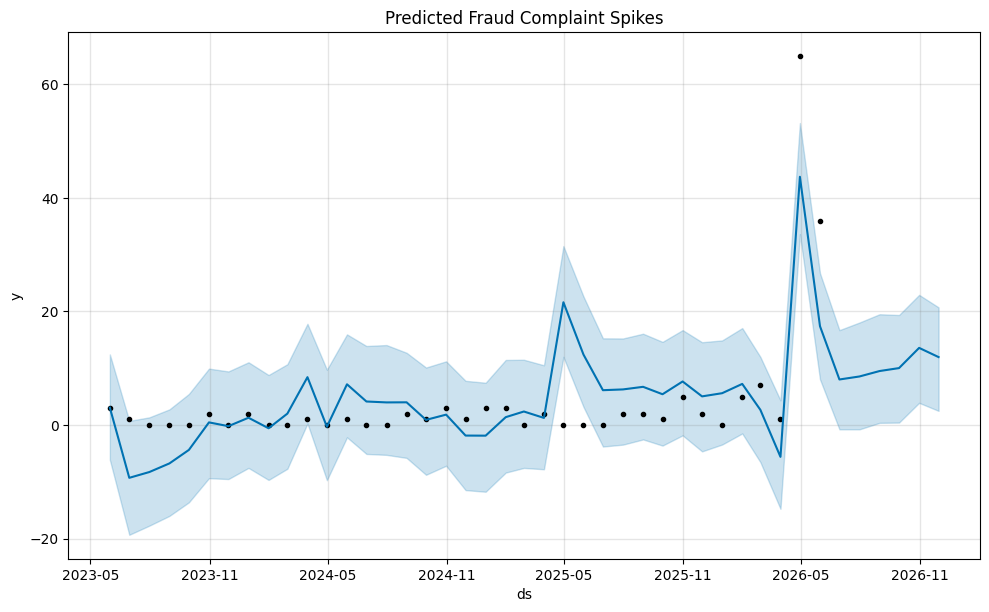

In [30]:
fraud_forecast = prophet_forecast(
    data=cleaned_df[cleaned_df['fraud_indicator'] == 1],
    date_col='at',
    title='Predicted Fraud Complaint Spikes'
)

The fraud forecasting model predicts future increases in fraud-related complaints, suggesting elevated consumer risk and the need for proactive monitoring by fintech providers and regulators.

Forecast M-Pesa Complaints

16:36:37 - cmdstanpy - INFO - Chain [1] start processing
16:36:37 - cmdstanpy - INFO - Chain [1] done processing


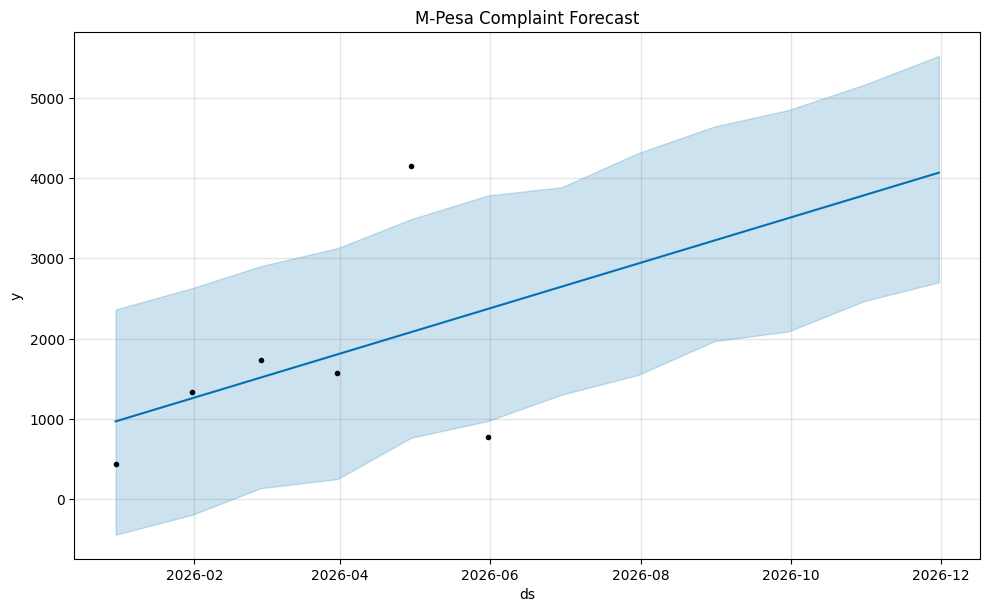

In [31]:
mpesa_forecast = prophet_forecast(
    data=cleaned_df[cleaned_df['app_name'] == 'mpesa'],
    date_col='at',
    title='M-Pesa Complaint Forecast'
)

Forecast Tala Complaints

16:38:12 - cmdstanpy - INFO - Chain [1] start processing
16:38:13 - cmdstanpy - INFO - Chain [1] done processing


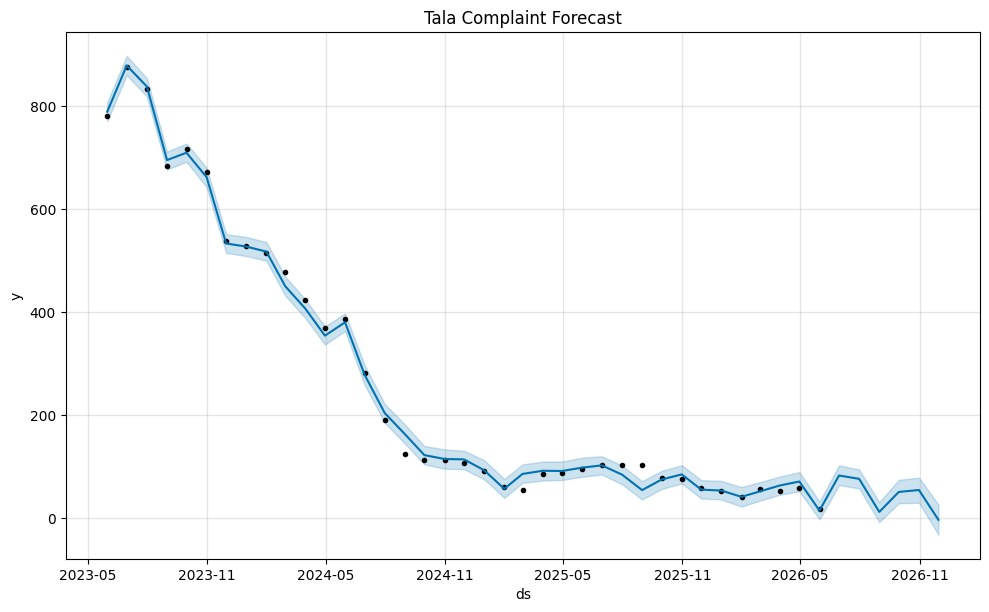

In [32]:
tala_forecast = prophet_forecast(
    data=cleaned_df[cleaned_df['app_name'] == 'tala'],
    date_col='at',
    title='Tala Complaint Forecast'
)

#### Business Insight

The forecasting analysis suggests that complaint activity within Kenya’s mobile money ecosystem may continue increasing over time, particularly for high-usage platforms such as M-Pesa. Fraud-related complaint spikes also appear periodically, indicating the need for proactive fraud monitoring and consumer protection interventions.

These findings demonstrate that fintech complaint data can be used not only for real-time sentiment analysis, but also for predictive risk monitoring and early warning systems.